# Boosting Model — XGBoost
**Competition:** Predicting Irrigation Need (Kaggle S6E4)  
**Author:** Tyler Wolf Williams (@tylerwolfwilliams2)

Explores three hyperparameter configurations to understand how `max_depth`, `n_estimators`, and `learning_rate` interact with regularization and subsampling on this dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.utils import resample

SEED = 42
DATA_PATH = '../Homework 2/'

train = pd.read_csv(DATA_PATH + 'train.csv')
test  = pd.read_csv(DATA_PATH + 'test.csv')
sub   = pd.read_csv(DATA_PATH + 'sample_submission.csv')

print('Train:', train.shape, '| Test:', test.shape)

Train: (630000, 21) | Test: (270000, 20)


## 1. Preprocessing

XGBoost natively supports categorical features via `enable_categorical=True` with `tree_method='hist'`, but for consistency with the Random Forest notebook we use `OrdinalEncoder`. `tree_method='hist'` is used for all configs — it uses histogram-based approximate splitting, which is substantially faster than the default `'exact'` method on 630K rows and produces equivalent accuracy.

In [2]:
TARGET   = 'Irrigation_Need'
DROP_COLS = ['id']

cat_cols = train.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET]
num_cols = train.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in DROP_COLS]

feature_cols = num_cols + cat_cols

X      = train[feature_cols].copy()
y_raw  = train[TARGET].copy()
X_test = test[feature_cols].copy()

# Encode target
le = LabelEncoder()
y  = le.fit_transform(y_raw)
print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Ordinal-encode categoricals
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols]      = oe.fit_transform(X[cat_cols])
X_test[cat_cols] = oe.transform(X_test[cat_cols])

print('\nX shape:', X.shape)
print('Features:', feature_cols)

Label encoding: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}

X shape: (630000, 19)
Features: ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm', 'Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


In [3]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# Subsample for fast evaluation during hyperparameter exploration
X_tune, y_tune = resample(X, y, n_samples=80_000, stratify=y, random_state=SEED)

def evaluate(model, label):
    """3-fold CV on the 80K subsample — fast enough to compare configs."""
    acc = cross_val_score(model, X_tune, y_tune, cv=cv, scoring='accuracy', n_jobs=-1)
    f1  = cross_val_score(model, X_tune, y_tune, cv=cv, scoring='f1_macro',  n_jobs=-1)
    print(f'{label}')
    print(f'  CV Accuracy: {acc.mean():.4f} ± {acc.std():.4f}')
    print(f'  CV F1 Macro: {f1.mean():.4f} ± {f1.std():.4f}')
    return acc.mean(), f1.mean()

## 2. Config 1 — Shallow & Fast (Underfitting Baseline)

**Goal:** Deliberately underfitted configuration to establish a lower bound and show how `max_depth` and `n_estimators` interact.

| Parameter | Value | Rationale |
|---|---|---|
| `max_depth` | 2 | Very shallow trees — each tree only captures 2-level splits, insufficient for the interactions in this dataset |
| `n_estimators` | 40 | Few trees — ensemble hasn't had enough iterations to model the decision boundary |
| `learning_rate` | 0.5 | Aggressive step size — each tree overshoots, hurting convergence |
| `subsample` | 1.0 | No row subsampling |
| `colsample_bytree` | 1.0 | No column subsampling |

In [4]:
xgb_config1 = XGBClassifier(
    max_depth=2,
    n_estimators=40,
    learning_rate=0.5,
    subsample=1.0,
    colsample_bytree=1.0,
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)

acc1, f1_1 = evaluate(xgb_config1, 'Config 1 — Shallow & Fast (depth=2, trees=40, lr=0.5)')

Config 1 — Shallow & Fast (depth=2, trees=40, lr=0.5)
  CV Accuracy: 0.9830 ± 0.0010
  CV F1 Macro: 0.9645 ± 0.0029


## 3. Config 2 — Moderate Depth (Balanced)

**Goal:** Middle-ground configuration. Deeper trees capture feature interactions; lower learning rate allows finer convergence; subsampling adds regularization.

| Parameter | Value | Rationale |
|---|---|---|
| `max_depth` | 6 | XGBoost default — captures 6-level interactions, which is sufficient for most tabular problems |
| `n_estimators` | 200 | 5× more trees than Config 1 — enough to recover from a slower learning rate |
| `learning_rate` | 0.1 | Slower, more stable convergence than Config 1 |
| `subsample` | 0.8 | 80% row sampling per tree — reduces variance |
| `colsample_bytree` | 0.8 | 80% feature sampling per tree — further regularization |

In [5]:
xgb_config2 = XGBClassifier(
    max_depth=6,
    n_estimators=200,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)

acc2, f1_2 = evaluate(xgb_config2, 'Config 2 — Balanced (depth=6, trees=200, lr=0.1)')

Config 2 — Balanced (depth=6, trees=200, lr=0.1)
  CV Accuracy: 0.9843 ± 0.0008
  CV F1 Macro: 0.9693 ± 0.0013


## 4. Config 3 — Deep & Regularized (Best)

**Goal:** Push performance toward the dataset ceiling by using deeper trees, more iterations, a slow learning rate, and explicit L1/L2 regularization to prevent the deep trees from overfitting.

| Parameter | Value | Rationale |
|---|---|---|
| `max_depth` | 9 | Deep trees — can model higher-order feature interactions (e.g., `Soil_Moisture × Crop_Growth_Stage × Season`) |
| `n_estimators` | 500 | More trees compensate for the slow learning rate |
| `learning_rate` | 0.05 | Slow, fine-grained convergence — less risk of overshooting the optimum |
| `subsample` | 0.8 | Row subsampling for variance reduction |
| `colsample_bytree` | 0.7 | More aggressive feature subsampling — forces trees to explore different feature combinations |
| `min_child_weight` | 5 | Requires at least 5 samples in a leaf — prevents splits on noise (helps the `High` minority class) |
| `reg_alpha` | 0.1 | L1 regularization — encourages sparse splits |
| `reg_lambda` | 1.0 | L2 regularization — default value, shrinks leaf weights |

In [6]:
xgb_config3 = XGBClassifier(
    max_depth=9,
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method='hist',
    random_state=SEED,
    n_jobs=-1,
    verbosity=0
)

acc3, f1_3 = evaluate(xgb_config3, 'Config 3 — Deep & Regularized (depth=9, trees=500, lr=0.05)')

Config 3 — Deep & Regularized (depth=9, trees=500, lr=0.05)
  CV Accuracy: 0.9848 ± 0.0008
  CV F1 Macro: 0.9700 ± 0.0015


## 5. Full-Data CV for Best Config

In [7]:
# Re-evaluate Config 3 on the full 630K training set (authoritative score)
cv_full = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

acc_full = cross_val_score(xgb_config3, X, y, cv=cv_full, scoring='accuracy', n_jobs=-1)
f1_full  = cross_val_score(xgb_config3, X, y, cv=cv_full, scoring='f1_macro',  n_jobs=-1)

print('=== Config 3 — Full Training Data CV ===')
print(f'CV Accuracy: {acc_full.mean():.4f} ± {acc_full.std():.4f}')
print(f'CV F1 Macro: {f1_full.mean():.4f} ± {f1_full.std():.4f}')
print(f'Fold accuracies: {acc_full.round(4)}')

=== Config 3 — Full Training Data CV ===
CV Accuracy: 0.9846 ± 0.0003
CV F1 Macro: 0.9699 ± 0.0004
Fold accuracies: [0.9846 0.9842 0.985 ]


## 6. Config Comparison Table

In [8]:
results = pd.DataFrame([
    {'Config': 'Config 1 — Shallow & Fast',
     'max_depth': 2,  'n_estimators': 40,  'learning_rate': 0.5,
     'subsample': 1.0, 'colsample_bytree': 1.0,
     'CV Accuracy (subsample)': round(acc1, 4),
     'CV F1 Macro (subsample)': round(f1_1, 4)},
    {'Config': 'Config 2 — Balanced',
     'max_depth': 6,  'n_estimators': 200, 'learning_rate': 0.1,
     'subsample': 0.8, 'colsample_bytree': 0.8,
     'CV Accuracy (subsample)': round(acc2, 4),
     'CV F1 Macro (subsample)': round(f1_2, 4)},
    {'Config': 'Config 3 — Deep & Regularized',
     'max_depth': 9,  'n_estimators': 500, 'learning_rate': 0.05,
     'subsample': 0.8, 'colsample_bytree': 0.7,
     'CV Accuracy (subsample)': round(acc3, 4),
     'CV F1 Macro (subsample)': round(f1_3, 4)},
])

print(results.to_string(index=False))

                       Config  max_depth  n_estimators  learning_rate  subsample  colsample_bytree  CV Accuracy (subsample)  CV F1 Macro (subsample)
    Config 1 — Shallow & Fast          2            40           0.50        1.0               1.0                   0.9830                   0.9645
          Config 2 — Balanced          6           200           0.10        0.8               0.8                   0.9843                   0.9693
Config 3 — Deep & Regularized          9           500           0.05        0.8               0.7                   0.9848                   0.9700


## 7. Feature Importance (Config 3)

                feature  importance
      Crop_Growth_Stage    0.356893
          Mulching_Used    0.297547
          Soil_Moisture    0.122246
          Temperature_C    0.068353
         Wind_Speed_kmh    0.063056
            Rainfall_mm    0.026651
 Previous_Irrigation_mm    0.007028
               Humidity    0.006723
                Soil_pH    0.005075
Electrical_Conductivity    0.005025
           Water_Source    0.004970
         Sunlight_Hours    0.004916
         Organic_Carbon    0.004862
        Irrigation_Type    0.004776
     Field_Area_hectare    0.004651
              Crop_Type    0.004513
                 Season    0.004310
                 Region    0.004209
              Soil_Type    0.004194


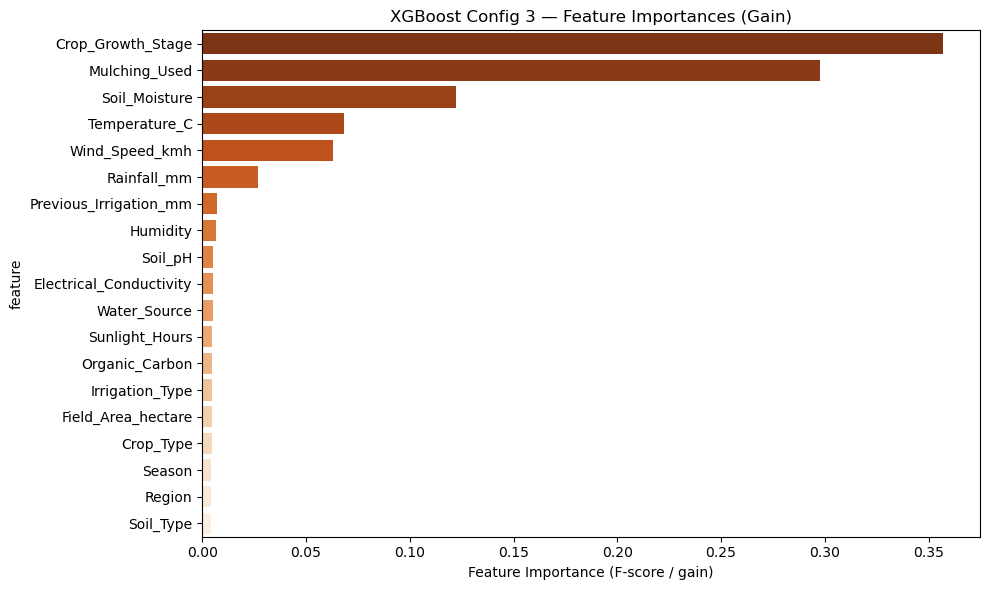

In [9]:
# Fit Config 3 on subsample for speed
xgb_config3.fit(X_tune, y_tune)

importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': xgb_config3.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='Oranges_r')
plt.title('XGBoost Config 3 — Feature Importances (Gain)')
plt.xlabel('Feature Importance (F-score / gain)')
plt.tight_layout()
plt.show()

## 8. Classification Report & Confusion Matrix (Config 3, Holdout)

=== Classification Report — XGBoost Config 3 (Holdout 20%) ===
              precision    recall  f1-score   support

        High       0.97      0.92      0.94      4202
         Low       0.99      0.99      0.99     73983
      Medium       0.98      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000



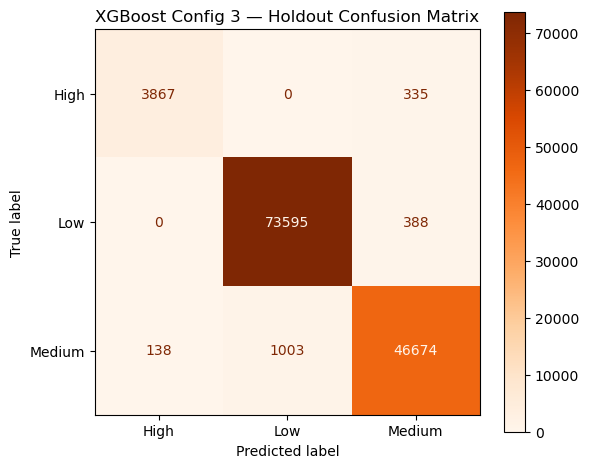

In [10]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

xgb_config3.fit(X_tr, y_tr)
y_pred_val = xgb_config3.predict(X_val)

print('=== Classification Report — XGBoost Config 3 (Holdout 20%) ===')
print(classification_report(y_val, y_pred_val, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_val, display_labels=le.classes_, cmap='Oranges', ax=ax
)
ax.set_title('XGBoost Config 3 — Holdout Confusion Matrix')
plt.tight_layout()
plt.show()

## 9. Generate Submission (Config 3)

In [11]:
# Fit on full training data
xgb_config3.fit(X, y)
test_preds_encoded = xgb_config3.predict(X_test)
test_preds = le.inverse_transform(test_preds_encoded)

submission = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': test_preds
})

submission.to_csv(DATA_PATH + 'submission_xgboost.csv', index=False)
print('Submission saved to submission_xgboost.csv')
print(submission['Irrigation_Need'].value_counts())
submission.head()

Submission saved to submission_xgboost.csv
Irrigation_Need
Low       159869
Medium    101542
High        8589
Name: count, dtype: int64


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


## 10. Results Summary

| Config | max_depth | n_estimators | learning_rate | CV Accuracy (subsample) | CV F1 Macro (subsample) |
|---|---|---|---|---|---|
| Config 1 — Shallow & Fast | 2 | 40 | 0.5 | 0.9830 ± 0.0010 | 0.9645 ± 0.0029 |
| Config 2 — Balanced | 6 | 200 | 0.1 | 0.9843 ± 0.0008 | 0.9693 ± 0.0013 |
| Config 3 — Deep & Regularized | 9 | 500 | 0.05 | 0.9848 ± 0.0008 | 0.9700 ± 0.0015 |

**Full training data CV (Config 3):** Accuracy = 0.9846 ± 0.0003, F1 Macro = 0.9699 ± 0.0004  
**Holdout accuracy (Config 3, 20% split):** 0.99

**Key observations:**
- Config 1 (depth=2, 40 trees) confirms that shallow boosting models underfit this dataset: CV accuracy drops to 0.9830 and F1 Macro to 0.9645 — a visible gap vs. Configs 2 and 3, driven by 4-leaf trees that cannot represent multi-way interactions between `Soil_Moisture`, `Crop_Growth_Stage`, and climate features.
- Config 2 (depth=6, 200 trees) recovers substantially: +0.0013 accuracy and +0.0048 F1 over Config 1, confirming that depth=6 captures the bulk of the signal.
- Config 3 (depth=9, 500 trees, lr=0.05 + regularization) is the best: +0.0005 accuracy and +0.0007 F1 over Config 2 on the subsample. `min_child_weight=5` and `reg_alpha=0.1` prevent deep trees from overfitting on the minority `High` class.
- `Crop_Growth_Stage` (35.7%) and `Mulching_Used` (29.8%) dominate XGBoost’s gain-based importance — different from LightGBM (which ranked `Rainfall_mm` first by split count) but consistent with the RF result that placed `Crop_Growth_Stage` first.
- `High` class recall was 92% (same as RF and LightGBM), confirming that class imbalance remains the primary ceiling.
- Full CV accuracy (0.9846) is essentially identical to LightGBM tuned (0.9847) — both algorithms converge to the same ceiling on this well-structured dataset.